# Phishing Email Detection: Handcrafted Rules vs. Learned Text Features

This notebook compares two ways of detecting phishing emails: six rule-style features (urgency words, URLs, etc.) versus TF-IDF text features learned from the data. It also measures how much phishing slips past keyword-based detection entirely.

## Stage 0: Setup and Inspection

Load the raw dataset and confirm its basic shape, class balance, missing values, duplicates, and length outliers before changing anything. Knowing these numbers up front lets us report exactly what cleaning removed later.

In [15]:
import pandas as pd

# Paths are relative to the notebooks/ folder
DATA_PATH = "../data/phishing_emails.csv"

# The first CSV column is an unnamed row index, so use it as the index instead of a data column
raw = pd.read_csv(DATA_PATH, index_col=0)

print("Shape (rows, columns):", raw.shape)
print("Columns:", list(raw.columns))

Shape (rows, columns): (18650, 2)
Columns: ['Email Text', 'Email Type']


In [16]:
# Class balance: how many emails of each type
print(raw["Email Type"].value_counts())

# Missing email bodies
print("\nNull Email Text values:", raw["Email Text"].isna().sum())

# Duplicate email bodies (counts every repeat after the first occurrence; nulls excluded)
non_null_text = raw["Email Text"].dropna()
print("Duplicate Email Text values:", non_null_text.duplicated().sum())

Safe Email        11322
Phishing Email     7328
Name: Email Type, dtype: int64

Null Email Text values: 16
Duplicate Email Text values: 1097


In [17]:
# Length of each email in characters, to spot extreme outliers
lengths = non_null_text.str.len()
print(lengths.describe())

# The five longest emails, with their label
longest = lengths.sort_values(ascending=False).head(5)
print("\nLongest emails:")
print(pd.DataFrame({"length": longest, "Email Type": raw.loc[longest.index, "Email Type"]}))

count    1.863400e+04
mean     2.755654e+03
std      1.248677e+05
min      1.000000e+00
25%      4.040000e+02
50%      8.815000e+02
75%      1.880000e+03
max      1.703669e+07
Name: Email Text, dtype: float64

Longest emails:
         length      Email Type
12501  17036692      Safe Email
11295    194978      Safe Email
8069     129635  Phishing Email
15994    120761      Safe Email
10805    107989      Safe Email


In [18]:
# Show the first few rows, cutting each email body to 200 characters so outputs stay readable
preview = raw.head(5).copy()
preview["Email Text"] = preview["Email Text"].str.slice(0, 200) + "..."
pd.set_option("display.max_colwidth", 210)
preview

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure tha...",Safe Email
1,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo * is ...,Safe Email
2,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only need 1 ...",Safe Email
3,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n Fantasy is my way of life, \n Ultimate in sex pl...",Phishing Email
4,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let still warm ...",Phishing Email


## Stage 1: Cleaning and Handcrafted Features

Remove empty emails, exact duplicates, and corrupted records before any train/test split, so the same email can never appear in both. Then turn each email into six simple numbers that mimic the rules a traditional email filter would use.

### 1.1 Inspect the extreme-length outlier

The longest "email" is about 17 million characters, roughly 87x longer than the next one. Before deciding what to do with it, look at what it actually contains.

In [19]:
# Find the longest email and count tell-tale patterns inside it
longest_id = raw["Email Text"].str.len().idxmax()
longest_text = raw.loc[longest_id, "Email Text"]

print("Row:", longest_id, "| Label:", raw.loc[longest_id, "Email Type"], "| Length:", f"{len(longest_text):,}")
print("Times 'Subject:' appears (one per embedded email):", longest_text.count("Subject:"))
print("Times a Jupyter notebook 'cell_type' key appears:", longest_text.count('cell_type'))
print("Start:", longest_text[:200], "...")

Row: 12501 | Label: Safe Email | Length: 17,036,692
Times 'Subject:' appears (one per embedded email): 5208
Times a Jupyter notebook 'cell_type' key appears: 21
Start: 0,"Subject: great part-time or summer job ! * * * * * * * * * * * * * * * we have display boxes with credit applications that we need to place in the small owner-operated stores in your area . here is ...


### 1.2 Clean the data

Drop missing emails, blank emails, and the 533 rows whose text is just the placeholder word "empty" (it appears under both labels, so it carries no signal). Then drop exact duplicates and anything over 1,000,000 characters. The 1,000,000 cutoff sits in a huge empty gap (the next-longest email is under 200,000 characters), so it removes only the corrupted record above and no real emails.

In [20]:
MAX_CHARS = 1_000_000  # Anything longer is a corrupted record, not an email (see 1.1)

df = raw.copy()
print(f"Starting rows: {len(df):,}")

# 1. Remove emails with no text at all
df = df.dropna(subset=["Email Text"])
print(f"After dropping nulls: {len(df):,}")

# 2. Remove emails that are blank or just the placeholder word "empty" (533 rows, labelled both ways)
stripped = df["Email Text"].str.strip().str.lower()
is_placeholder = (stripped == "") | (stripped == "empty")
print(f"Blank or 'empty' placeholder rows removed: {is_placeholder.sum()}")
df = df[~is_placeholder]
print(f"After dropping blank/placeholder emails: {len(df):,}")

# 3. Check whether any identical text carries BOTH labels (that would be a labelling conflict)
labels_per_text = df.groupby("Email Text")["Email Type"].nunique()
print(f"Distinct texts with conflicting labels: {(labels_per_text > 1).sum()}")

# 4. Remove exact duplicate email bodies, keeping the first copy
df = df.drop_duplicates(subset=["Email Text"], keep="first")
print(f"After dropping duplicates: {len(df):,}")

# 5. Remove the corrupted extreme-length record(s)
too_long = df["Email Text"].str.len() > MAX_CHARS
print(f"Rows over {MAX_CHARS:,} characters removed: {too_long.sum()}")
df = df[~too_long].reset_index(drop=True)
print(f"Final rows: {len(df):,}")

# Label: 1 = Phishing, 0 = Safe
df["label"] = (df["Email Type"] == "Phishing Email").astype(int)
print("\nClass counts after cleaning:")
print(df["Email Type"].value_counts())

Starting rows: 18,650
After dropping nulls: 18,634
Blank or 'empty' placeholder rows removed: 536
After dropping blank/placeholder emails: 18,098
Distinct texts with conflicting labels: 0


After dropping duplicates: 17,535
Rows over 1,000,000 characters removed: 1
Final rows: 17,534

Class counts after cleaning:
Safe Email        10978
Phishing Email     6556
Name: Email Type, dtype: int64


### 1.3 Build the six handcrafted features

Each feature is a rule a human analyst might write: count urgent phrases, count links, flag links that point to a raw IP address, count exclamation marks, measure length, and count requests for sensitive information. Many emails in this dataset write URLs with spaces (e.g. `http : / / www . site . com`), so the URL patterns allow optional spaces.

In [21]:
import re

URGENCY_PHRASES = [
    "urgent", "immediately", "verify", "suspend", "confirm", "expire", "act now",
    "action required", "limited time", "unusual activity", "security alert",
    "click here", "update your", "validate", "locked", "unauthorized",
]
BAIT_PHRASES = [
    "password", "ssn", "social security", "credit card", "bank account",
    "wire transfer", "invoice", "refund", "prize", "winner", "inheritance",
]

def phrase_pattern(phrases):
    # \b = the match must start at the beginning of a word, so "locked" does not match inside "unlocked".
    # The end is left open on purpose, so "confirmed", "expires" and "winners" still count.
    # Spaces inside a phrase become \s+ so "act  now" (extra spaces) still matches.
    return r"\b(?:" + "|".join(p.replace(" ", r"\s+") for p in phrases) + ")"

URGENCY_PATTERN = phrase_pattern(URGENCY_PHRASES)
BAIT_PATTERN = phrase_pattern(BAIT_PHRASES)

# URL patterns, tolerant of spaces around ":" "/" and "."
URL_SCHEME = r"https?\s*:\s*/\s*/"                                  # http:// or "http : / /"
WWW_START = r"\bwww\s*\."                                           # www. or "www ."
SCHEME_THEN_WWW = URL_SCHEME + r"\s*www\s*\."                        # http://www. (would be counted twice)
IP_URL = URL_SCHEME + r"\s*\d{1,3}(?:\s*\.\s*\d{1,3}){3}"            # http://192.168.0.1

text = df["Email Text"].str.lower()

df["urgency_score"] = text.str.count(URGENCY_PATTERN)
# Count links that start with http(s):// plus bare www. links, without double-counting http://www.
df["url_count"] = text.str.count(URL_SCHEME) + text.str.count(WWW_START) - text.str.count(SCHEME_THEN_WWW)
df["has_ip_url"] = text.str.contains(IP_URL, regex=True).astype(int)
df["exclamation_count"] = text.str.count("!")
df["email_length"] = text.str.len()
df["bait_score"] = text.str.count(BAIT_PATTERN)

FEATURES = ["urgency_score", "url_count", "has_ip_url", "exclamation_count", "email_length", "bait_score"]
df[FEATURES].describe().round(2)

,urgency_score,url_count,has_ip_url,exclamation_count,email_length,bait_score
count,17534.00,17534.00,17534.00,17534.00,17534.00,17534.00
mean,0.30,1.11,0.01,1.68,1890.84,0.15
std,1.06,23.86,0.10,6.94,4352.62,1.03
min,0.00,0.00,0.00,0.00,4.00,0.00
25%,0.00,0.00,0.00,0.00,435.00,0.00
50%,0.00,0.00,0.00,0.00,916.00,0.00
75%,0.00,1.00,0.00,1.00,1945.75,0.00
max,57.00,3134.00,1.00,414.00,194978.00,87.00


### 1.4 Compare features by class

If a feature is useful, its average should differ clearly between phishing and safe emails. Means are sensitive to a few huge values, so medians are shown alongside them.

In [22]:
# Mean and median of each feature, split by class
comparison = df.groupby("Email Type")[FEATURES].agg(["mean", "median"]).T.round(2)
comparison

Email Type                Phishing Email  Safe Email
urgency_score     mean              0.53        0.17
                  median            0.00        0.00
url_count         mean              0.83        1.27
                  median            0.00        0.00
has_ip_url        mean              0.02        0.00
                  median            0.00        0.00
exclamation_count mean              3.43        0.63
                  median            1.00        0.00
email_length      mean           1698.12     2005.93
                  median          764.00     1021.00
bait_score        mean              0.24        0.10
                  median            0.00        0.00

In [23]:
# Share of each class with at least one hit on each count feature (easier to read than averages)
hit_rates = (df[FEATURES].drop(columns="email_length") > 0).groupby(df["Email Type"]).mean().T.round(3)
hit_rates

Email Type,Phishing Email,Safe Email
urgency_score,0.294,0.103
url_count,0.379,0.417
has_ip_url,0.024,0.001
exclamation_count,0.604,0.223
bait_score,0.105,0.043


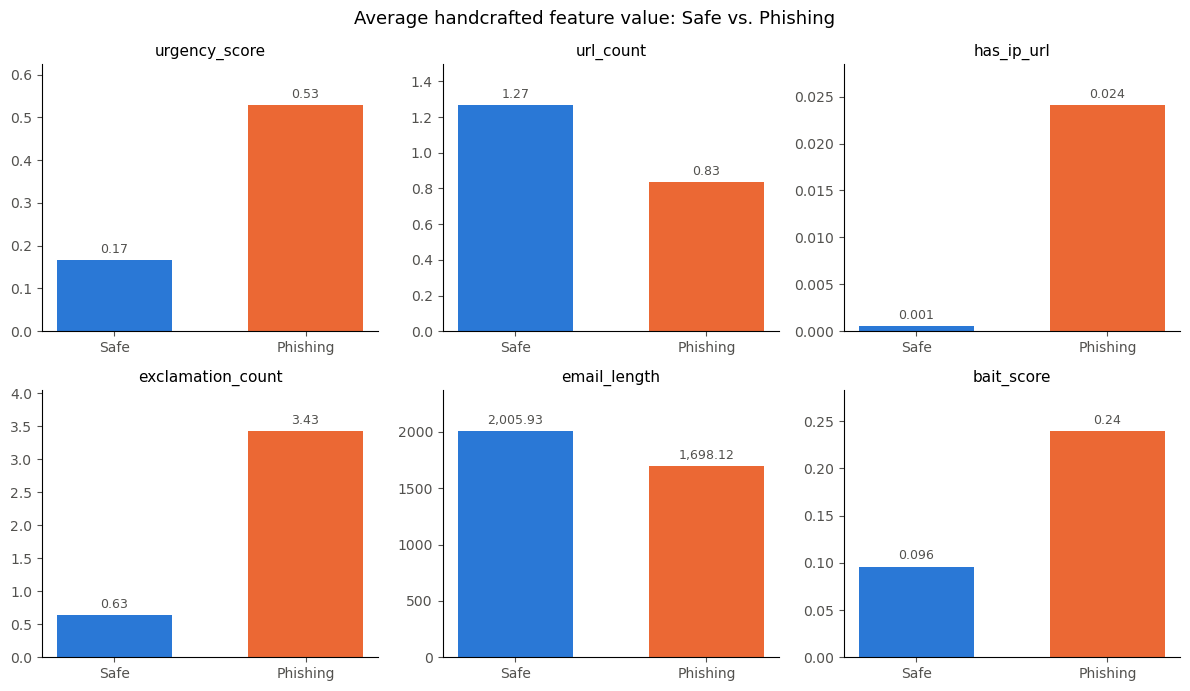

In [24]:
import matplotlib.pyplot as plt
import os

os.makedirs("../dashboard", exist_ok=True)

# One small panel per feature, because the features are on very different scales
# (tiny values like has_ip_url get 3 decimals so they don't round to 0.00)
CLASS_ORDER = ["Safe Email", "Phishing Email"]
CLASS_COLORS = {"Safe Email": "#2a78d6", "Phishing Email": "#eb6834"}
means = df.groupby("Email Type")[FEATURES].mean().loc[CLASS_ORDER]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, feature in zip(axes.flat, FEATURES):
    values = means[feature]
    bars = ax.bar(["Safe", "Phishing"], values, color=[CLASS_COLORS[c] for c in CLASS_ORDER], width=0.6)
    ax.bar_label(bars, labels=[f"{v:,.3f}" if v < 0.1 else f"{v:,.2f}" for v in values], padding=3, fontsize=9, color="#52514e")
    ax.set_title(feature, fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors="#52514e")
    ax.set_ylim(0, values.max() * 1.18)

fig.suptitle("Average handcrafted feature value: Safe vs. Phishing", fontsize=13)
fig.tight_layout()
fig.savefig("../dashboard/feature_comparison.png", dpi=150, facecolor="white")
plt.show()

## Stage 2: SQL Analysis

Load the labels and the six features into a SQLite database and answer three questions in SQL: how the classes compare, which phishing emails look riskiest, and how much phishing has no rule-based red flags at all. The queries live in `queries/analysis.sql` and this notebook runs that file directly, so the two can never disagree.

In [25]:
import sqlite3

DB_PATH = "../data/phishing.db"
SQL_PATH = "../queries/analysis.sql"

# Store only the label and features, never the email text
table = df[["Email Type", "label"] + FEATURES].rename(columns={"Email Type": "email_type"})
table.insert(0, "email_id", df.index)

conn = sqlite3.connect(DB_PATH)
table.to_sql("emails", conn, if_exists="replace", index=False)
print("Rows in emails table:", conn.execute("SELECT COUNT(*) FROM emails").fetchone()[0])

# Window functions (NTILE, SUM() OVER) were added in SQLite 3.25.0, so check the version and test one
print("SQLite version:", sqlite3.sqlite_version)
print("Window function test:", conn.execute("SELECT NTILE(2) OVER (ORDER BY x) FROM (SELECT 1 AS x UNION SELECT 2)").fetchall())

Rows in emails table: 17534
SQLite version: 3.39.3
Window function test: [(1,), (2,)]


In [26]:
import os

os.makedirs("../results", exist_ok=True)

# Read the SQL file and split it into individual queries on the semicolons
with open(SQL_PATH) as f:
    queries = [q.strip() for q in f.read().split(";") if q.strip()]

# Comment-only chunks (e.g. a trailing comment) are not queries, so keep only chunks containing SELECT
queries = [q for q in queries if "SELECT" in q.upper()]
names = ["sql_summary_by_type", "sql_top5pct_risk_phishing", "sql_evasive_phishing"]
assert len(queries) == len(names), f"Expected {len(names)} queries, found {len(queries)}"

# Run each query and save the result to results/<name>.csv
sql_results = {}
for name, query in zip(names, queries):
    sql_results[name] = pd.read_sql_query(query, conn)
    sql_results[name].to_csv(f"../results/{name}.csv", index=False)
    print(f"Saved results/{name}.csv ({len(sql_results[name])} rows)")

Saved results/sql_summary_by_type.csv (2 rows)
Saved results/sql_top5pct_risk_phishing.csv (328 rows)
Saved results/sql_evasive_phishing.csv (1 rows)


### 2.1 Summary by email type

In [27]:
sql_results["sql_summary_by_type"]

,email_type,email_count,pct_of_total,avg_urgency_score,avg_url_count,avg_has_ip_url,avg_exclamation_count,avg_email_length,avg_bait_score,pct_with_ip_url
0,Phishing Email,6556,37.39,0.529,0.834,0.0241,3.430,1698.1,0.240,2.41
1,Safe Email,10978,62.61,0.166,1.267,0.0005,0.635,2005.9,0.096,0.05


### 2.2 Top 5% highest-risk phishing

The riskiest 5% of phishing emails by urgency, then bait phrases. A quick profile of the group is more useful than scrolling all of its rows.

In [28]:
top5 = sql_results["sql_top5pct_risk_phishing"]
print(f"Emails in top 5%: {len(top5)} of {int(df['label'].sum())} phishing")
print(f"Lowest urgency_score that made the cut: {top5['urgency_score'].min()}")
top5.drop(columns="email_id").describe().loc[["mean", "min", "max"]].round(2)

Emails in top 5%: 328 of 6556 phishing
Lowest urgency_score that made the cut: 2


,urgency_score,bait_score,url_count,has_ip_url,exclamation_count,email_length
mean,4.23,0.91,1.51,0.05,9.18,4123.14
min,2.00,0.00,0.00,0.00,0.00,215.00
max,57.00,12.00,45.00,1.00,92.00,72743.00


### 2.3 Evasive phishing

Phishing emails with zero urgency phrases, zero links and no IP links. A rule-based filter built on these signals has nothing to flag in them.

In [29]:
sql_results["sql_evasive_phishing"]

,evasive_count,total_phishing,pct_of_phishing
0,2915,6556,44.46


In [30]:
conn.close()